# One F1 unit, end to end: features → distributional forecast → score

**Unit:** `t2-F1-hawkish-cut-2024` — UST 2Y yield (level, % p.a.) at **126** and **189** business
days after the as-of date **2024-12-18**. Numeric panel only; the text corpus is deliberately
ignored here.

What this notebook answers:

1. **What does the model see?** — the panel, the target definition, and a feature set built
   strictly from data at or before the forecast origin.
2. **What does the model produce?** — a *joint sample matrix* `(n_draws, 1 asset, 2 horizons)`,
   which is the only thing the scorer reads.
3. **Which model works on this data?** — three models of increasing information, compared in a
   rolling-origin backtest using the scorer's own metric code:
   - **M0** the repo's reference Gaussian random walk (unconditional scale, horizons independent)
   - **M1** conditional-volatility bootstrap paths (conditional scale, empirical shape, joint by construction)
   - **M2** feature-driven location-scale regression (conditional mean *and* scale, joint residual bootstrap)

The conditional/unconditional distinction from the risk-management notes is exactly the M0 → M1/M2 step:
M0 draws tomorrow's change from $F_{\mathbf X}$; M1 and M2 draw from $F_{\mathbf X_{t+1}\mid\mathcal F_t}$.

## 0 — Setup

In [35]:
import json, pathlib, tomllib, subprocess, sys, time
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

# repo code: the reference forecaster and the scorer's metric functions
from qfbench2_track_forecasting.cli import _read_panels, _draw
from qfbench2_track_forecasting.tail import TAIL_METRICS
from qfbench2_common.scoring import crps

REPO = pathlib.Path.cwd()
UNIT = REPO / "units/t2-F1-hawkish-cut-2024"
OUT  = REPO / "out-hawkish-cut"

# chart chrome — one categorical colour per model, fixed order; text in ink, not series colour
C = {"M0": "#2a78d6", "M1": "#eb6834", "M2": "#1baf7a"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
                     "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.titlecolor": INK,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})
pd.set_option("display.width", 140)

## 1 — The unit: what the model is given

Every unit ships a `card.toml` (the contract), one or more panel parquets (the numbers), and a
text folder (ignored here). The card fixes the asset, the horizons, the target type, and the
scoring weights.

In [36]:
card  = tomllib.loads((UNIT / "card.toml").read_text())
ASSET = card["targets"]["asset_ids"][0]
HS    = [int(h) for h in card["targets"]["horizons"]]
ASOF  = pd.Timestamp(card["provenance"]["data_cutoff"])
W_    = card["scoring"]["params"]["weights"]
WEIGHTS = (W_["marginal"], W_["joint"], W_["tail"])
TAIL_LEVELS = tuple(card["scoring"]["params"]["tail_levels"])

print(card["task"]["title"])
print(f"asset={ASSET}  horizons={HS} BD  target_type={card['targets']['target_type']}  "
      f"unit={card['targets']['value_unit']}  as-of={ASOF.date()}")
print(f"score = {WEIGHTS[0]}·marginal CRPS + {WEIGHTS[1]}·variogram + {WEIGHTS[2]}·tail pinball@{TAIL_LEVELS}   (lower is better)")
print(f"n_draws_min = {card['scoring']['params']['n_draws_min']}")

UST 2Y After a Cut Paired with Shallower Rate-Path Guidance (126/189 BD)
asset=UST_2Y  horizons=[126, 189] BD  target_type=level  unit=percent_per_annum  as-of=2024-12-18
score = 0.5·marginal CRPS + 0.3·variogram + 0.2·tail pinball@(0.01, 0.05, 0.95, 0.99)   (lower is better)
n_draws_min = 200


In [37]:
card

{'schema_version': '2.0',
 'task': {'id': 't2-F1-hawkish-cut-2024',
  'track': 'forecasting',
  'title': 'UST 2Y After a Cut Paired with Shallower Rate-Path Guidance (126/189 BD)',
  'split': 'public-dev'},
 'metadata': {'author_name': 'Ruolan Sun',
  'author_email': 'ruolan.sun@stonybrook.edu',
  'difficulty': 'medium',
  'category': 'T2-F1',
  'tags': ['forecasting',
   'rates_daily',
   't2-f1',
   't2c-F1-guidance-shift-2024'],
  'expert_time_estimate_min': 45.0,
  'junior_time_estimate_min': 120.0,
  'asset_panel': 'rates_daily',
  'horizons': [126, 189],
  'n_assets': 1,
  'target_type': 'level',
  'target_frequency': 'daily',
  'description': 'UST 2Y After a Cut Paired with Shallower Rate-Path Guidance (126/189 BD). As-of 2024-12-18; targets UST_2Y at horizons [126, 189] BD. Dot-plot language shift: the text argues fewer cuts than the easing narrative assumed.',
  'created_by': 'Ruolan Sun (catalog t2c-F1-guidance-shift-2024)',
  'created_date': '2026-07-03'},
 'provenance': {'l

In [38]:
raw = pd.read_parquet(UNIT / "rates_daily.parquet")
raw["date"] = pd.to_datetime(raw["date"].astype(str).str[:10])
W = raw.pivot(index="date", columns="asset", values="value").sort_index()
W = W[["UST_2Y", "UST_5Y", "UST_7Y", "UST_10Y", "UST_20Y", "UST_30Y"]]
y = W[ASSET]
print(f"{len(W):,} business days, {W.index.min().date()} → {W.index.max().date()}, "
      f"{W.isna().sum().sum()} missing values")
W.tail(5)

6,245 business days, 2000-01-03 → 2024-12-18, 0 missing values


asset,UST_2Y,UST_5Y,UST_7Y,UST_10Y,UST_20Y,UST_30Y
date,,,,,,
2024-12-12,4.18,4.18,4.25,4.32,4.62,4.55
2024-12-13,4.25,4.25,4.33,4.40,4.69,4.61
2024-12-16,4.25,4.25,4.32,4.39,4.68,4.60
2024-12-17,4.25,4.26,4.33,4.40,4.68,4.59
2024-12-18,4.35,4.40,4.45,4.50,4.74,4.65


In [39]:
raw

,date,asset,value,panel_id
0,2000-01-03,UST_10Y,6.58,rates_daily
1,2000-01-03,UST_20Y,6.94,rates_daily
2,2000-01-03,UST_2Y,6.38,rates_daily
3,2000-01-03,UST_30Y,6.61,rates_daily
4,2000-01-03,UST_5Y,6.50,rates_daily
...,...,...,...,...
37465,2024-12-18,UST_20Y,4.74,rates_daily
37466,2024-12-18,UST_2Y,4.35,rates_daily
37467,2024-12-18,UST_30Y,4.65,rates_daily
37468,2024-12-18,UST_5Y,4.40,rates_daily


In [40]:
W

asset,UST_2Y,UST_5Y,UST_7Y,UST_10Y,UST_20Y,UST_30Y
date,,,,,,
2000-01-03,6.38,6.50,6.65,6.58,6.94,6.61
2000-01-04,6.30,6.40,6.56,6.49,6.84,6.53
2000-01-05,6.38,6.51,6.68,6.62,6.95,6.64
2000-01-06,6.35,6.46,6.63,6.57,6.86,6.58
2000-01-07,6.31,6.42,6.58,6.52,6.82,6.55
...,...,...,...,...,...,...
2024-12-12,4.18,4.18,4.25,4.32,4.62,4.55
2024-12-13,4.25,4.25,4.33,4.40,4.69,4.61
2024-12-16,4.25,4.25,4.32,4.39,4.68,4.60


### 1.1 — The target

`target_type = level`, so the value to forecast is simply the **2Y yield on the date h business
days after the as-of**. Equivalently, the as-of level plus the h-day change:

$$y_{T+h} = y_T + \Delta_h, \qquad \Delta_h := y_{T+h} - y_T .$$

Everything below models $\Delta_h$. The plot on the right shows every historical realisation of
$\Delta_{126}$ and $\Delta_{189}$ — the *unconditional* distribution M0 effectively samples from —
and how differently it behaved across eras.

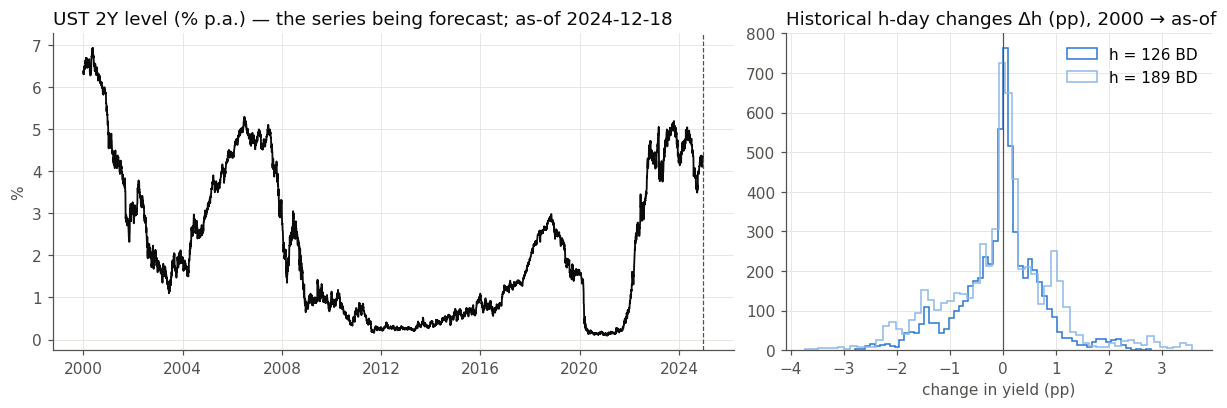

Δh by era — the spread is not constant, which is the case for a conditional model:


,Δ126 mean,Δ126 std,Δ189 mean,Δ189 std
2000-07,-0.27,0.91,-0.39,1.18
2008-15,-0.09,0.42,-0.14,0.43
2016-21,0.11,0.77,0.22,1.11
2022-24,0.41,0.94,0.62,1.10


In [41]:
d = y.diff()
fwd = pd.DataFrame({h: y.shift(-h) - y for h in HS})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained", gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
ax.plot(y.index, y, color=INK, lw=1.2)
ax.axvline(ASOF, color=INK2, lw=0.8, ls="--")
ax.set_title(f"UST 2Y level (% p.a.) — the series being forecast; as-of {ASOF.date()}")
ax.set_ylabel("%")
ax = axes[1]
for h, col in zip(HS, ["#2a78d6", "#8fb8ea"]):
    ax.hist(fwd[h].dropna(), bins=60, histtype="step", lw=1.6, color=col, label=f"h = {h} BD")
ax.axvline(0, color=INK2, lw=0.8)
ax.set_title("Historical h-day changes Δh (pp), 2000 → as-of")
ax.set_xlabel("change in yield (pp)"); ax.legend()
plt.show()

eras = pd.cut(fwd.index, [pd.Timestamp("1999"), pd.Timestamp("2008"), pd.Timestamp("2016"),
                           pd.Timestamp("2022"), pd.Timestamp("2026")],
              labels=["2000-07", "2008-15", "2016-21", "2022-24"])
tab = fwd.groupby(eras, observed=True).agg(["mean", "std"]).round(2)
tab.columns = [f"Δ{h} {s}" for h, s in tab.columns]
print("Δh by era — the spread is not constant, which is the case for a conditional model:")
tab

## 2 — Features

All features are functions of data **at or before** the row's date, so a feature row dated $t$ is
what a forecaster standing at $t$ could compute. Two groups:

| group | feature | intent |
|---|---|---|
| **mean** (where is the 2Y going?) | `level` | mean-reversion of the yield level |
| | `slope_10_2`, `slope_5_2`, `curv` | curve shape — a steep curve tends to precede a rising 2Y and vice-versa |
| | `mom_21/63/126/252` | momentum / trend over 1, 3, 6, 12 months |
| | `z_252` | level vs its 1-year mean, in standard deviations |
| **scale** (how wide should the band be?) | `rv_21/63/252` | realised daily volatility over 1, 3, 12 months |
| | `ewma_vol` | RiskMetrics-style EWMA volatility (λ = 0.94) |
| | `vol_ratio` | short/long vol — is volatility currently elevated? |
| | `log_level` | yields near zero move less (the 2009-15 and 2020-21 floors) |

In [42]:
W

asset,UST_2Y,UST_5Y,UST_7Y,UST_10Y,UST_20Y,UST_30Y
date,,,,,,
2000-01-03,6.38,6.50,6.65,6.58,6.94,6.61
2000-01-04,6.30,6.40,6.56,6.49,6.84,6.53
2000-01-05,6.38,6.51,6.68,6.62,6.95,6.64
2000-01-06,6.35,6.46,6.63,6.57,6.86,6.58
2000-01-07,6.31,6.42,6.58,6.52,6.82,6.55
...,...,...,...,...,...,...
2024-12-12,4.18,4.18,4.25,4.32,4.62,4.55
2024-12-13,4.25,4.25,4.33,4.40,4.69,4.61
2024-12-16,4.25,4.25,4.32,4.39,4.68,4.60


In [43]:
def make_features(W: pd.DataFrame, asset: str = "UST_2Y") -> pd.DataFrame:
    y = W[asset]; d = y.diff()
    F = pd.DataFrame(index=W.index)
    F["level"]      = y
    F["slope_10_2"] = W["UST_10Y"] - W["UST_2Y"]
    F["slope_5_2"]  = W["UST_5Y"]  - W["UST_2Y"]
    F["curv"]       = 2 * W["UST_5Y"] - W["UST_2Y"] - W["UST_10Y"]
    for k in (21, 63, 126, 252):
        F[f"mom_{k}"] = y - y.shift(k)
    F["z_252"]      = (y - y.rolling(252).mean()) / y.rolling(252).std()
    for k in (21, 63, 252):
        F[f"rv_{k}"]  = d.rolling(k).std()
    F["ewma_vol"]   = d.ewm(alpha=1 - 0.94).std()
    F["vol_ratio"]  = F["rv_21"] / F["rv_252"]
    F["log_level"]  = np.log(y.clip(lower=0.05))
    return F

MEAN_COLS = ["level", "slope_10_2", "slope_5_2", "curv", "mom_21", "mom_63", "mom_126", "mom_252", "z_252"]
VOL_COLS  = ["log_level", "rv_21", "rv_63", "rv_252", "ewma_vol", "vol_ratio"]

F = make_features(W)
print("feature row at the as-of date — this is the model's input vector for the final forecast:")
F.loc[[ASOF]].T.rename(columns={ASOF: str(ASOF.date())}).round(4)

feature row at the as-of date — this is the model's input vector for the final forecast:


date,2024-12-18
level,4.3500
slope_10_2,0.1500
slope_5_2,0.0500
curv,-0.0500
mom_21,0.0600
mom_63,0.7600
mom_126,-0.4000
mom_252,-0.0200
z_252,-0.0602
rv_21,0.0531


In [44]:
W

asset,UST_2Y,UST_5Y,UST_7Y,UST_10Y,UST_20Y,UST_30Y
date,,,,,,
2000-01-03,6.38,6.50,6.65,6.58,6.94,6.61
2000-01-04,6.30,6.40,6.56,6.49,6.84,6.53
2000-01-05,6.38,6.51,6.68,6.62,6.95,6.64
2000-01-06,6.35,6.46,6.63,6.57,6.86,6.58
2000-01-07,6.31,6.42,6.58,6.52,6.82,6.55
...,...,...,...,...,...,...
2024-12-12,4.18,4.18,4.25,4.32,4.62,4.55
2024-12-13,4.25,4.25,4.33,4.40,4.69,4.61
2024-12-16,4.25,4.25,4.32,4.39,4.68,4.60


In [45]:
F

,level,slope_10_2,slope_5_2,curv,mom_21,mom_63,mom_126,mom_252,z_252,rv_21,rv_63,rv_252,ewma_vol,vol_ratio,log_level
date,,,,,,,,,,,,,,,
2000-01-03,6.38,0.20,0.12,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.853168
2000-01-04,6.30,0.19,0.10,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.840550
2000-01-05,6.38,0.24,0.13,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.113137,NaN,1.853168
2000-01-06,6.35,0.22,0.11,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.081021,NaN,1.848455
2000-01-07,6.31,0.21,0.11,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.067039,NaN,1.842136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12,4.18,0.14,0.00,-0.14,-0.16,0.56,-0.63,-0.53,-0.516145,0.050784,0.054599,0.063959,0.049398,0.794011,1.430311
2024-12-13,4.25,0.15,0.00,-0.15,-0.02,0.61,-0.50,-0.46,-0.328975,0.051372,0.055124,0.064120,0.050658,0.801178,1.446919
2024-12-16,4.25,0.14,0.00,-0.14,-0.09,0.68,-0.43,-0.48,-0.324483,0.048741,0.054189,0.064105,0.049134,0.760330,1.446919


### 2.1 — Is there any signal in them?

Two quick diagnostics on the full history (in-sample, so read them as *plausibility*, not proof):

- rank correlation of each feature with the **forward change** $\Delta_h$ → information about the *mean*
- rank correlation with the **absolute forward change** $|\Delta_h|$ → information about the *scale*

Yield-level series are highly persistent, so the "mean" correlations are inflated by overlap;
the backtest in §4 is the real test.

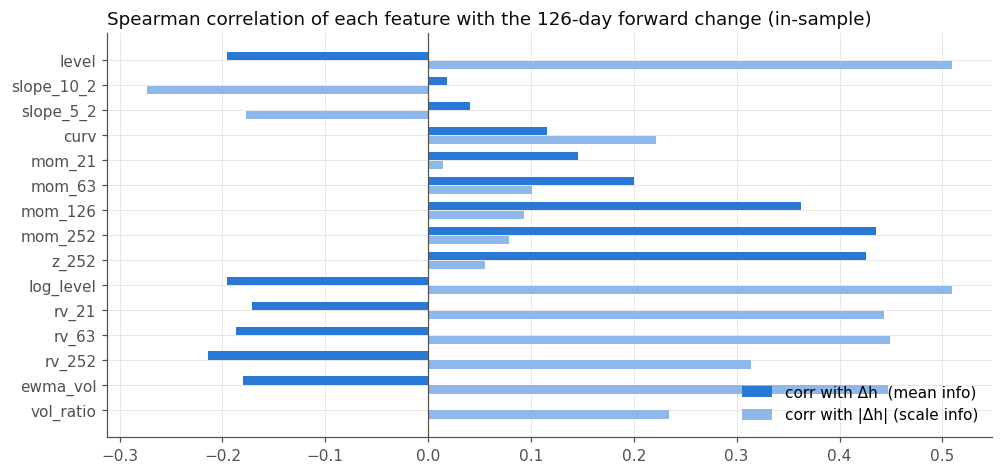

,corr with Δh (mean info),corr with |Δh| (scale info)
level,-0.196,0.509
slope_10_2,0.018,-0.273
slope_5_2,0.041,-0.177
curv,0.116,0.222
mom_21,0.146,0.014
mom_63,0.200,0.101
mom_126,0.363,0.093
mom_252,0.435,0.079
z_252,0.426,0.055
log_level,-0.196,0.509


In [46]:
h0 = HS[0]
J = F.join(fwd[h0].rename("fwd")).dropna()
sig = pd.DataFrame({
    "corr with Δh  (mean info)":  J[MEAN_COLS + VOL_COLS].corrwith(J["fwd"], method="spearman"),
    "corr with |Δh| (scale info)": J[MEAN_COLS + VOL_COLS].corrwith(J["fwd"].abs(), method="spearman"),
}).round(3)

fig, ax = plt.subplots(figsize=(9, 4.2), layout="constrained")
ypos = np.arange(len(sig))
ax.barh(ypos - 0.18, sig.iloc[:, 0], height=0.34, color="#2a78d6", label=sig.columns[0])
ax.barh(ypos + 0.18, sig.iloc[:, 1], height=0.34, color="#8fb8ea", label=sig.columns[1])
ax.axvline(0, color=INK2, lw=0.8); ax.set_yticks(ypos, sig.index); ax.invert_yaxis()
ax.set_title(f"Spearman correlation of each feature with the {h0}-day forward change (in-sample)")
ax.legend(loc="lower right"); plt.show()
sig

The pattern is sensible: **vol features carry scale information** (`rv_*`, `ewma_vol`, and
`log_level` — low yields, low moves), while **level, slope and momentum carry (weak) mean
information** — a high level and a flat/inverted curve tend to precede a lower 2Y. Weak mean
signal + strong scale signal is the usual shape for rates at a 6–9 month horizon, and it tells us
where the modelling effort should go.

## 3 — Three models

All three return the same object — a `(n_draws, len(HS))` array of joint samples of $y_{T+h}$ — so
they can be scored identically.

### M0 — the repo's reference: Gaussian random walk (unconditional)

`qfbench2_track_forecasting.cli._draw`: daily changes since 2000 → one standard deviation
$\hat\sigma$ → $y_{T+h} \sim \mathcal N(y_T,\, \hat\sigma^2 h)$. Two things to notice in
[cli.py](qfbench2_track_forecasting/cli.py): the scale is *unconditional* (25 years pooled), and
the innovation `z` is drawn **separately for each horizon**, so the h=126 and h=189 cells are
independent even though one is a prefix of the other.

In [47]:
panels = _read_panels(UNIT)

def m0_samples(origin: pd.Timestamp, n: int, seed: int) -> np.ndarray:
    s, _ = _draw(panels, [ASSET], HS, str(origin.date()), n, seed, target_type="level")
    return s[:, 0, :]                                   # (n, len(HS))

s0 = m0_samples(ASOF, 2000, 0)
print("M0 at as-of:  corr(h126, h189) =", np.corrcoef(s0.T)[0, 1].round(3),
      "  (a path model implies ≈ sqrt(126/189) =", np.sqrt(126/189).round(3), ")")

M0 at as-of:  corr(h126, h189) = -0.017   (a path model implies ≈ sqrt(126/189) = 0.816 )


### M1 — conditional-volatility bootstrap paths

Filtered historical simulation, kept deliberately parameter-light:

1. **Today's conditional vol** $\sigma_T^2$ from an EWMA of squared daily changes (λ = 0.94).
2. **Vol term structure**: over the horizon, $\sigma^2_{T+k}$ decays from $\sigma_T^2$ toward the
   5-year average $\bar\sigma^2$ at rate $\phi = 0.995$ per day (a GARCH-style mean reversion, with
   $\phi$ fixed rather than fitted).
3. **Shape** from the data: standardise historical changes by their own EWMA vol, $z_t = \Delta y_t/\sigma_t$,
   and **block-bootstrap** (10-day blocks) 189-day paths of $z$.
4. Rescale each step by $\sigma_{T+k}$, cumulate, read off day 126 and day 189 of the *same path*.

No mean: the drift is zero, as in M0. Joint across horizons by construction, fat tails from the
empirical $z$.

In [48]:
def cond_vol_path(d: pd.Series, lam=0.94, phi=0.995, H=189, long_win=1260) -> np.ndarray:
    v    = d.ewm(alpha=1 - lam).var().iloc[-1]          # sigma_T^2
    vbar = (d.tail(long_win) ** 2).mean()               # long-run variance
    k    = np.arange(1, H + 1)
    return np.sqrt(vbar + (v - vbar) * phi ** k)        # sigma_{T+k}, k = 1..H

def m1_samples(yh: pd.Series, n: int, rng, block=10, lam=0.94, phi=0.995) -> np.ndarray:
    d   = yh.diff().dropna()
    sig = np.sqrt(d.ewm(alpha=1 - lam).var().shift(1)).iloc[252:]      # sigma_t uses info to t-1
    z   = (d.loc[sig.index] / sig).to_numpy(); z = z[np.isfinite(z)]; z -= z.mean()
    H   = max(HS); sig_f = cond_vol_path(d, lam, phi, H)
    nb  = int(np.ceil(H / block))
    starts = rng.integers(0, len(z) - block, size=(n, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(n, -1)[:, :H]
    paths = np.cumsum(z[idx] * sig_f[None, :], axis=1)                  # (n, H)
    return yh.iloc[-1] + paths[:, [h - 1 for h in HS]]

# what the vol term structure looks like today vs. the unconditional number M0 uses
sig_f = cond_vol_path(y.loc[:ASOF].diff().dropna())
print(f"M0 daily sd (pooled 2000→as-of): {y.loc[:ASOF].diff().std():.4f} pp")
print(f"M1 sigma_T (EWMA today):        {sig_f[0]:.4f} pp   →  sigma_T+189: {sig_f[-1]:.4f} pp")
print(f"implied sd at h=126: M0 {y.loc[:ASOF].diff().std()*np.sqrt(126):.3f}  vs  M1 {np.sqrt((sig_f[:126]**2).sum()):.3f}")

M0 daily sd (pooled 2000→as-of): 0.0548 pp
M1 sigma_T (EWMA today):        0.0516 pp   →  sigma_T+189: 0.0601 pp
implied sd at h=126: M0 0.615  vs  M1 0.621


### M2 — feature-driven location-scale model

A **direct** model per horizon $h$ (no path): every historical date $t$ with $t+h \le$ origin is a
training row with input $x_t$ (the feature vector) and target $\Delta_h(t)$.

$$\Delta_h(t) = \mu_h(x_t) + \sigma_h(x_t)\,\varepsilon_{h,t}$$

1. **Mean** $\mu_h(x) = \beta_h^\top x$ — ridge regression on the *mean* features. Because targets
   overlap (6,000 rows but only ~30 independent 189-day windows) the ridge penalty is essential;
   λ = n·1 is used and its sensitivity is checked in §4.3.
2. **Scale** $\log\sigma_h^2(x) = \gamma_h^\top x$ — ridge regression of $\log r^2$ on the *vol*
   features, where $r$ are the mean-model residuals; a constant rescales so $\mathrm{Var}(r/\sigma)=1$.
   This is also ridge-shrunk (λ = n·10): §4.3 shows that a *fully* conditional scale under-covers at
   this horizon, for the same reason M1 does.
3. **Shape** — the standardised residuals $\varepsilon_{h,t} = r_{h,t}/\sigma_{h,t}$ are kept as an
   empirical distribution: no Gaussian assumption.
4. **Joint draw** — pick a historical date $t^\*$ at random and use $(\varepsilon_{126,t^\*}, \varepsilon_{189,t^\*})$
   *together*: the dependence between the two horizons is inherited from history.

Output for a draw: $y_T + \mu_h(x_T) + \sigma_h(x_T)\,\varepsilon_{h,t^\*}$ for each $h$.

In [49]:
def ridge_fit(X, t, lam):
    Xb = np.c_[np.ones(len(X)), X]
    A  = Xb.T @ Xb + lam * np.diag([0.0] + [1.0] * X.shape[1])       # intercept unpenalised
    return np.linalg.solve(A, Xb.T @ t)

def ridge_pred(b, X):
    return np.c_[np.ones(len(X)), X] @ b

def m2_fit(y: pd.Series, F: pd.DataFrame, origin: pd.Timestamp, lam_mu=1.0, lam_sig=10.0) -> dict:
    Hmax = max(HS)
    yo = y.loc[:origin]; Fo = F.loc[:origin].dropna()
    pos = {dt: i for i, dt in enumerate(yo.index)}
    tr  = Fo.index[[pos[dt] + Hmax < len(yo) for dt in Fo.index]]       # target fully observed by origin
    Xm, Xv = Fo.loc[tr, MEAN_COLS].to_numpy(), Fo.loc[tr, VOL_COLS].to_numpy()
    mm, sm = Xm.mean(0), Xm.std(0) + 1e-12; mv, sv = Xv.mean(0), Xv.std(0) + 1e-12
    Xm, Xv = (Xm - mm) / sm, (Xv - mv) / sv
    xm = (Fo.loc[[origin], MEAN_COLS].to_numpy() - mm) / sm
    xv = (Fo.loc[[origin], VOL_COLS].to_numpy() - mv) / sv
    ya, ti = yo.to_numpy(), np.array([pos[dt] for dt in tr])
    eps = np.empty((len(ti), len(HS))); out = {"n_train": len(ti), "per_h": {}}
    for j, h in enumerate(HS):
        t  = ya[ti + h] - ya[ti]
        bm = ridge_fit(Xm, t, lam_mu * len(t));  r  = t - ridge_pred(bm, Xm)
        bv = ridge_fit(Xv, np.log(r ** 2 + 1e-8), lam_sig * len(t))
        sig = np.exp(ridge_pred(bv, Xv) / 2); c = np.sqrt(np.mean((r / sig) ** 2)); sig *= c
        eps[:, j] = r / sig
        out["per_h"][h] = dict(mu=float(ridge_pred(bm, xm)[0]), sig=float(np.exp(ridge_pred(bv, xv)[0] / 2) * c),
                               beta_mu=pd.Series(bm[1:], MEAN_COLS), beta_sig=pd.Series(bv[1:], VOL_COLS))
    out["eps"] = eps; out["y_T"] = float(yo.iloc[-1])
    return out

def m2_samples(fit: dict, n: int, rng) -> np.ndarray:
    pick = rng.integers(0, len(fit["eps"]), size=n)                      # one date -> both horizons
    mu  = np.array([fit["per_h"][h]["mu"]  for h in HS])
    sig = np.array([fit["per_h"][h]["sig"] for h in HS])
    return fit["y_T"] + mu[None, :] + sig[None, :] * fit["eps"][pick]

fit = m2_fit(y, F, ASOF)
print(f"training rows: {fit['n_train']:,}  (feature dates t with t+189 ≤ as-of)")
coef = pd.DataFrame({f"β_mu h={h}": fit["per_h"][h]["beta_mu"] for h in HS}).round(3)
coef_v = pd.DataFrame({f"γ_sig h={h}": fit["per_h"][h]["beta_sig"] for h in HS}).round(3)
print("\nmean-model coefficients (per 1 sd of the feature, in pp of yield change):"); display(coef)
print("scale-model coefficients (per 1 sd of the feature, on log σ²):"); display(coef_v)
print("\nat the as-of date:")
for h in HS:
    p = fit["per_h"][h]
    print(f"  h={h}: μ = {p['mu']:+.3f} pp   σ = {p['sig']:.3f} pp   →  centre {fit['y_T'] + p['mu']:.2f} %")

training rows: 5,804  (feature dates t with t+189 ≤ as-of)

mean-model coefficients (per 1 sd of the feature, in pp of yield change):


,β_mu h=126,β_mu h=189
level,-0.111,-0.169
slope_10_2,0.005,0.023
slope_5_2,0.006,0.025
curv,0.006,0.020
mom_21,-0.006,0.009
mom_63,-0.008,0.036
mom_126,0.051,0.085
mom_252,0.111,0.140
z_252,0.125,0.171


scale-model coefficients (per 1 sd of the feature, on log σ²):


,γ_sig h=126,γ_sig h=189
log_level,0.080,0.049
rv_21,0.056,0.019
rv_63,0.062,0.022
rv_252,0.044,0.008
ewma_vol,0.059,0.020
vol_ratio,0.037,0.032



at the as-of date:
  h=126: μ = -0.230 pp   σ = 0.656 pp   →  centre 4.12 %
  h=189: μ = -0.302 pp   σ = 0.791 pp   →  centre 4.05 %


Reading the coefficients: the mean model is dominated by **`level` and `z_252` (negative)** — the
2Y mean-reverts — and a **positive `slope_10_2`** — a steeper curve precedes a higher 2Y.

Momentum terms are small. At the as-of (2Y at 4.35 % with an inverted-to-flat curve) this
translates into a **downward centre of ≈ −0.2 / −0.3 pp**. The scale model's largest term is
`log_level` (low yields → narrow bands); the vol features enter with small positive weights, so the
band at the as-of — moderate yield, unremarkable vol — is close to the unconditional width.

## 4 — Rolling-origin backtest with the scorer's own metrics

Every ~21 business days from 2006 to the last origin whose 189-day outcome is observed
(≈ 217 origins), each model is fit **only on data at or before the origin**, draws 1,000
samples, and is scored against the realised 2Y at +126 and +189 with the repo's own functions:
`crps_marginal`, `variogram_score(p=0.5)` and `tail_pinball` at the card's weights.

Two caveats worth saying out loud: origins 21 days apart share most of their outcome window, so
the 217 scores are far from independent; and the public units have no realised references, so
this pseudo-out-of-sample test on the unit's own history is the only accuracy check available.

In [50]:
def score(samples: np.ndarray, y_real: np.ndarray) -> dict:
    s, yr = np.asarray(samples, float), np.asarray(y_real, float)
    m = crps.crps_marginal(s, yr); j = crps.variogram_score(s, yr, p=0.5)
    t = TAIL_METRICS["pinball"](s, yr, TAIL_LEVELS)
    q05, q95 = np.quantile(s, [0.05, 0.95], axis=0)
    return dict(marginal=m, joint=j, tail=t, composite=WEIGHTS[0]*m + WEIGHTS[1]*j + WEIGHTS[2]*t,
                cov90=float(np.mean((yr >= q05) & (yr <= q95))), width90=float(np.mean(q95 - q05)),
                pit_h0=float(np.mean(s[:, 0] <= yr[0])))

dates = y.index; Hmax = max(HS)
origins = [o for o in dates[dates >= "2006-01-01"][::21] if dates.get_loc(o) + Hmax < len(dates)]

def run_backtest(models: dict, n=1000) -> pd.DataFrame:
    rows = []
    for i, o in enumerate(origins):
        loc = dates.get_loc(o); y_real = np.array([y.iloc[loc + h] for h in HS]); yh = y.loc[:o]
        for name, fn in models.items():
            rng = np.random.default_rng(i)
            r = score(fn(o, yh, rng, i, n), y_real); r.update(model=name, origin=o); rows.append(r)
    return pd.DataFrame(rows)

MODELS = {
    "M0 reference GRW":         lambda o, yh, rng, i, n: m0_samples(o, n, i),
    "M1 cond-vol paths":        lambda o, yh, rng, i, n: m1_samples(yh, n, rng),
    "M2 feature loc-scale":     lambda o, yh, rng, i, n: m2_samples(m2_fit(y, F, o), n, rng),
}
t0 = time.time(); bt = run_backtest(MODELS); print(f"{len(origins)} origins × {len(MODELS)} models in {time.time()-t0:.1f}s")

summary = bt.groupby("model")[["marginal", "joint", "tail", "composite", "cov90", "width90"]].mean()
piv = bt.pivot(index="origin", columns="model", values="composite")
summary["composite / M0"] = piv.div(piv["M0 reference GRW"], axis=0).mean()
summary["share of origins beating M0"] = piv.lt(piv["M0 reference GRW"], axis=0).mean()
summary.round(3)

217 origins × 3 models in 2.8s


,marginal,joint,tail,composite,cov90,width90,composite / M0,share of origins beating M0
model,,,,,,,,
M0 reference GRW,0.447,0.443,0.080,0.372,0.853,2.355,1.000,0.000
M1 cond-vol paths,0.442,0.177,0.094,0.293,0.772,1.861,0.730,0.728
M2 feature loc-scale,0.419,0.183,0.075,0.279,0.853,1.959,0.723,0.788


### 4.1 — Where the gain comes from

The composite splits into three terms; the plot shows each model's *average* of each term.

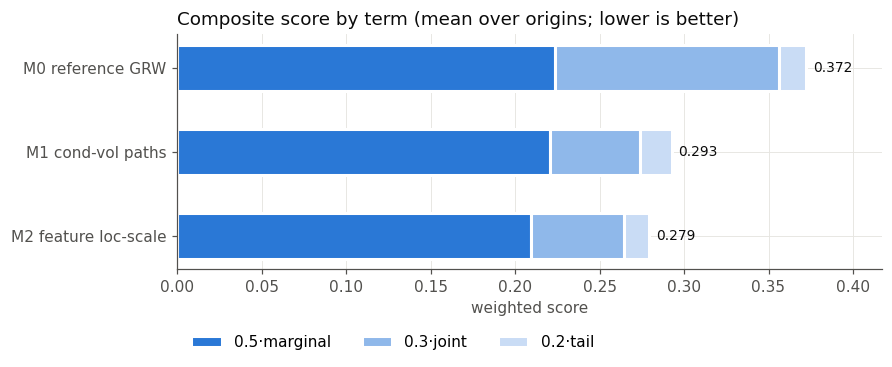

In [51]:
terms = summary[["marginal", "joint", "tail"]].mul(list(WEIGHTS), axis=1)
terms.columns = [f"{w}·{c}" for c, w in zip(["marginal", "joint", "tail"], WEIGHTS)]
fig, ax = plt.subplots(figsize=(8, 3.2), layout="constrained")
left = np.zeros(len(terms)); shades = ["#2a78d6", "#8fb8ea", "#c9dcf5"]
for col, sh in zip(terms.columns, shades):
    ax.barh(terms.index, terms[col], left=left, color=sh, label=col, height=0.55, edgecolor="white", linewidth=2)
    left += terms[col].to_numpy()
for i, v in enumerate(left):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", color=INK, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, left.max() * 1.12)
ax.set_title("Composite score by term (mean over origins; lower is better)")
ax.set_xlabel("weighted score"); ax.legend(ncols=3, loc="upper left", bbox_to_anchor=(0, -0.22)); plt.show()

- **Joint term (30 % weight)** — the largest single improvement. M0 draws the two horizons
  independently; M1 (same path) and M2 (same historical residual date) preserve the ≈0.8
  correlation between $y_{T+126}$ and $y_{T+189}$, and the variogram term drops by more than half.
- **Marginal CRPS (50 %)** — M2 is the only model that improves it meaningfully, via the shrunk mean.
- **Tail pinball (20 %)** — M1 is *worse* than M0: its bands are too narrow (90 % coverage of
  ~77 %), because a 6–9 month horizon is long enough that volatility has mostly reverted to its
  long-run level; conditioning on today's vol mainly helps at short horizons.

### 4.2 — Through time

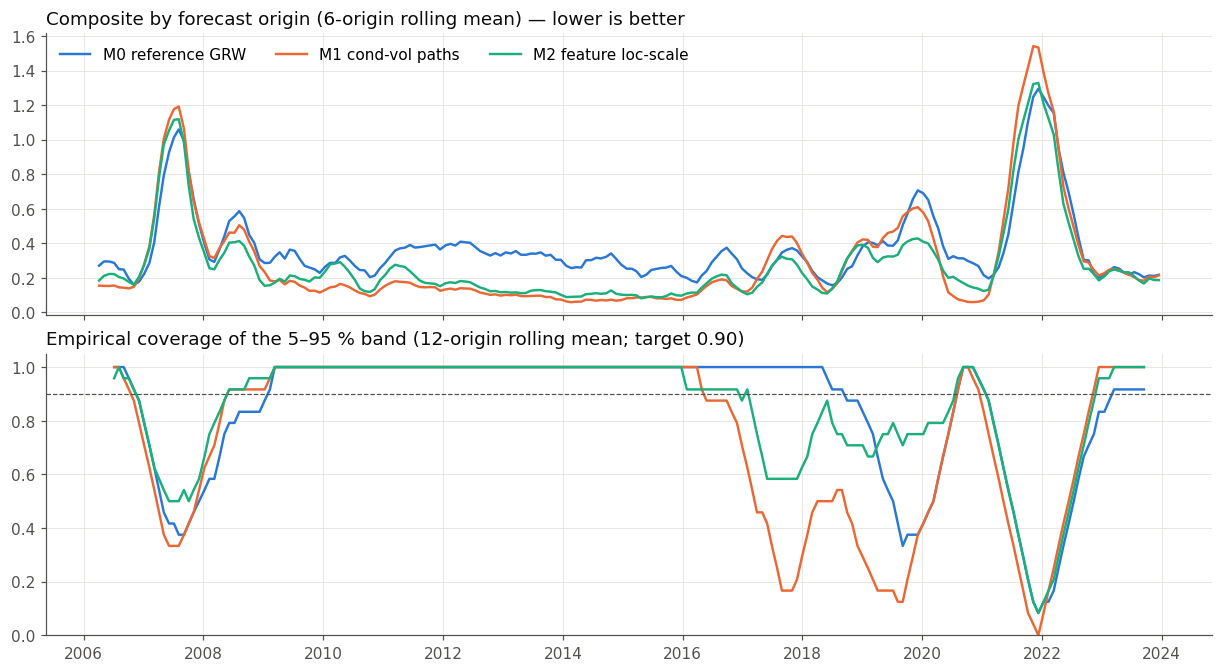

mean composite by era:


model,M0 reference GRW,M1 cond-vol paths,M2 feature loc-scale
era,,,
2006-08,0.451,0.451,0.417
2009-15,0.312,0.116,0.154
2016-20,0.332,0.279,0.240
2021-24,0.496,0.555,0.487


In [52]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), layout="constrained", sharex=True)
ax = axes[0]
for name, col in zip(MODELS, C.values()):
    s = piv[name].rolling(6, center=True).mean()
    ax.plot(s.index, s, color=col, lw=1.6, label=name)
ax.set_title("Composite by forecast origin (6-origin rolling mean) — lower is better"); ax.legend(ncols=3)
ax = axes[1]
cov = bt.pivot(index="origin", columns="model", values="cov90")
for name, col in zip(MODELS, C.values()):
    ax.plot(cov.index, cov[name].rolling(12, center=True).mean(), color=col, lw=1.6, label=name)
ax.axhline(0.9, color=INK2, lw=0.8, ls="--"); ax.set_ylim(0, 1.05)
ax.set_title("Empirical coverage of the 5–95 % band (12-origin rolling mean; target 0.90)")
plt.show()

era = pd.cut(bt["origin"], [pd.Timestamp("2005"), pd.Timestamp("2009"), pd.Timestamp("2016"),
                           pd.Timestamp("2021"), pd.Timestamp("2025")], labels=["2006-08", "2009-15", "2016-20", "2021-24"])
print("mean composite by era:")
bt.assign(era=era).pivot_table(index="era", columns="model", values="composite", observed=True).round(3)

The eras tell the conditional/unconditional story directly. In **2009-15** (2Y pinned near zero)
the unconditional M0 band is absurdly wide and both conditional models score ~2–3× better. In
**2021-24** (the hiking cycle) all three are hurt, and M0's pooled 25-year sigma is *by accident*
about right for the regime, so the conditional models lose their edge there.

### 4.3 — The two ridge penalties

M2 has two tuning knobs: the penalty on the mean model (`lam_mu`) and on the scale model
(`lam_sig`), both as multiples of $n$. With heavily overlapping targets it is easy to overfit the
mean; and a scale model that tracks today's vol too closely narrows the bands too much at this
horizon. Both tables vary one knob with the other held at its default.

In [53]:
sens = {f"M2 lam_mu={lm:g}": (lambda lm: (lambda o, yh, rng, i, n: m2_samples(m2_fit(y, F, o, lam_mu=lm), n, rng)))(lm)
        for lm in (100.0, 1.0, 0.1, 0.01)}
sens["M2 no mean (μ=0)"] = lambda o, yh, rng, i, n: m2_samples(m2_fit(y, F, o, lam_mu=1e9), n, rng)
sens2 = {f"M2 lam_sig={ls:g}": (lambda ls: (lambda o, yh, rng, i, n: m2_samples(m2_fit(y, F, o, lam_sig=ls), n, rng)))(ls)
         for ls in (0.01, 1.0, 10.0, 100.0)}
sens2["M2 constant σ (lam_sig→∞)"] = lambda o, yh, rng, i, n: m2_samples(m2_fit(y, F, o, lam_sig=1e9), n, rng)

def sens_table(models):
    b = run_backtest(models); ps = b.pivot(index="origin", columns="model", values="composite")
    t = b.groupby("model")[["marginal", "joint", "tail", "composite", "cov90", "width90"]].mean()
    t["composite / M0"] = ps.div(piv["M0 reference GRW"], axis=0).mean()
    return t.loc[list(models)].round(3)

print("mean-model penalty (lam_sig = 10):"); display(sens_table(sens))
print("scale-model penalty (lam_mu = 1):");  sens_table(sens2)

mean-model penalty (lam_sig = 10):


,marginal,joint,tail,composite,cov90,width90,composite / M0
model,,,,,,,
M2 lam_mu=100,0.464,0.178,0.085,0.302,0.866,2.485,0.785
M2 lam_mu=1,0.419,0.183,0.075,0.279,0.853,1.959,0.723
M2 lam_mu=0.1,0.451,0.198,0.071,0.299,0.825,1.745,0.823
M2 lam_mu=0.01,0.498,0.211,0.076,0.328,0.756,1.717,0.948
M2 no mean (μ=0),0.467,0.178,0.085,0.304,0.866,2.503,0.790


scale-model penalty (lam_mu = 1):


,marginal,joint,tail,composite,cov90,width90,composite / M0
model,,,,,,,
M2 lam_sig=0.01,0.428,0.179,0.094,0.287,0.717,1.487,0.733
M2 lam_sig=1,0.421,0.175,0.084,0.280,0.781,1.617,0.714
M2 lam_sig=10,0.419,0.183,0.075,0.279,0.853,1.959,0.723
M2 lam_sig=100,0.421,0.191,0.073,0.282,0.880,2.174,0.738
M2 constant σ (lam_sig→∞),0.422,0.192,0.073,0.283,0.882,2.212,0.741


- **Mean:** `lam_mu = 1` is the sweet spot; below it the mean model starts fitting the overlap
  and the marginal CRPS deteriorates quickly. Dropping the mean altogether costs ~10 % — the
  mean-reversion signal is small but real at this horizon.
- **Scale:** the composite is almost flat in `lam_sig`, but coverage is not. A nearly
  unpenalised scale model (0.01) tracks current vol closely, narrows the band and covers only ~72 %
  — the same failure as M1. As the penalty grows the band widens back toward unconditional and
  coverage recovers. `lam_sig = 10` keeps real coefficients with ~85 % coverage; the difference
  between 10 and 100 is inside the noise of 217 overlapping origins.

The lesson for this horizon: **conditioning helps the mean and the joint structure more than the
scale.** Six to nine months out, volatility has mostly reverted, so today's vol is only a weak
guide to the width of the band.

## 5 — The forecast at the as-of date

Fit M2 on everything up to 2024-12-18, draw 2,000 joint samples, and compare the three models'
predictive distributions.

In [54]:
N_DRAWS = 2000
rng = np.random.default_rng(2024)
fit = m2_fit(y, F, ASOF)
S = {"M0 reference GRW": m0_samples(ASOF, N_DRAWS, 0),
     "M1 cond-vol paths": m1_samples(y.loc[:ASOF], N_DRAWS, rng),
     "M2 feature loc-scale": m2_samples(fit, N_DRAWS, rng)}

qs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
rows = {}
for name, s in S.items():
    for j, h in enumerate(HS):
        rows[(name, h)] = np.quantile(s[:, j], qs)
qtab = pd.DataFrame(rows, index=[f"q{int(q*100):02d}" for q in qs]).T.round(2)
qtab.index.names = ["model", "horizon"]
print(f"as-of 2Y = {y.loc[ASOF]:.2f} %.  Predictive quantiles of the 2Y yield (%):")
qtab

as-of 2Y = 4.35 %.  Predictive quantiles of the 2Y yield (%):


q01   q05   q25   q50   q75   q95   q99
model                horizon                                          
M0 reference GRW     126      2.88  3.34  3.92  4.33  4.76  5.33  5.74
                     189      2.74  3.13  3.83  4.33  4.85  5.62  6.15
M1 cond-vol paths    126      2.90  3.30  3.94  4.34  4.73  5.34  5.74
                     189      2.49  3.07  3.83  4.35  4.86  5.61  6.09
M2 feature loc-scale 126      2.28  2.96  3.78  4.12  4.48  5.19  6.15
                     189      1.57  2.80  3.63  4.03  4.49  5.26  6.56

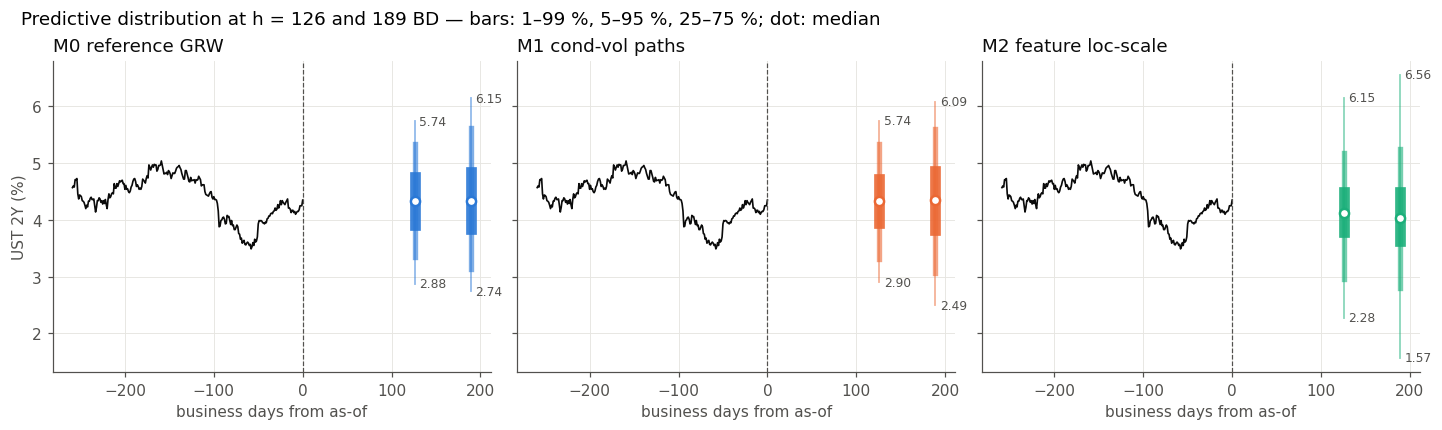

In [55]:
hist_n = 260
yh = y.loc[:ASOF].tail(hist_n); x_hist = np.arange(-hist_n + 1, 1)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout="constrained", sharey=True)
for ax, (name, s), col in zip(axes, S.items(), C.values()):
    ax.plot(x_hist, yh, color=INK, lw=1.1)
    for j, h in enumerate(HS):
        q = np.quantile(s[:, j], [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        ax.plot([h, h], [q[0], q[-1]], color=col, lw=1.2, alpha=0.5)
        ax.plot([h, h], [q[1], q[-2]], color=col, lw=3.5, alpha=0.6)
        ax.plot([h, h], [q[2], q[-3]], color=col, lw=7, alpha=0.9)
        ax.plot(h, q[3], "o", color="white", mec=col, ms=6, mew=1.6)
        ax.text(h + 5, q[-1], f"{q[-1]:.2f}", color=INK2, fontsize=8, va="center")
        ax.text(h + 5, q[0], f"{q[0]:.2f}", color=INK2, fontsize=8, va="center")
    ax.axvline(0, color=INK2, lw=0.8, ls="--"); ax.set_title(name); ax.set_xlabel("business days from as-of")
axes[0].set_ylabel("UST 2Y (%)")
fig.suptitle("Predictive distribution at h = 126 and 189 BD — bars: 1–99 %, 5–95 %, 25–75 %; dot: median", x=0.01, ha="left")
plt.show()

What to read off the panel: M0 and M1 are centred on today's 4.35 % (random walk); M2's centre is
**~4.1 % at 6 months and ~4.05 % at 9 months** — the mean-reversion terms pull it down — with a
5–95 % band of roughly **3.0 – 5.2 %**, about as wide as M0's but shifted, and with a visibly
**fatter lower tail** (1st percentile at 9 months ≈ 1.6 % vs M0's 2.7 %): the empirical residuals
remember 2008 and 2020, a Gaussian does not. M1's band is the narrowest, which is exactly what the
backtest flagged as under-coverage.

### 5.1 — Joint structure: the thing the variogram term scores

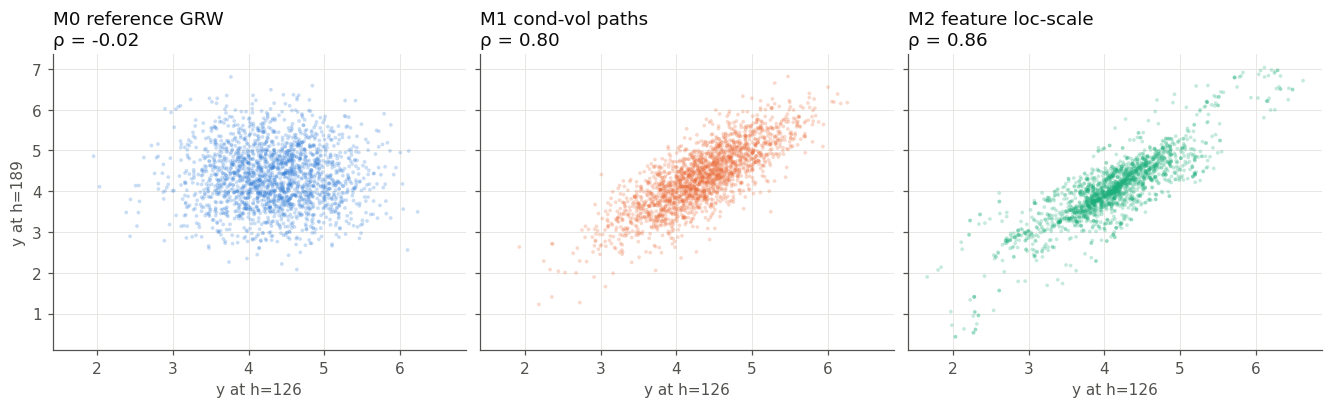

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), layout="constrained", sharex=True, sharey=True)
for ax, (name, s), col in zip(axes, S.items(), C.values()):
    ax.scatter(s[:, 0], s[:, 1], s=6, alpha=0.25, color=col, edgecolors="none")
    ax.set_title(f"{name}\nρ = {np.corrcoef(s.T)[0,1]:.2f}"); ax.set_xlabel(f"y at h={HS[0]}")
axes[0].set_ylabel(f"y at h={HS[1]}")
plt.show()

## 6 — Write the submission and run the scorer's gates

The output contract: `forecast.parquet` with columns `[draw:int32, asset:string, horizon:int32,
value:float64]` plus `forecast_meta.json` and a rationale. The public scorer has no realised
outcomes, so it runs the four admissibility gates only.

In [57]:
OUT.mkdir(exist_ok=True)
best = "M2 feature loc-scale"; s_best = S[best]
pd.DataFrame([{"draw": np.int32(dr), "asset": ASSET, "horizon": np.int32(h), "value": float(s_best[dr, j])}
              for dr in range(N_DRAWS) for j, h in enumerate(HS)]).to_parquet(OUT / "forecast.parquet", index=False)

meta = {"unit_id": card["task"]["id"], "asof": str(ASOF.date()), "representation": "samples",
        "asset_ids": [ASSET], "horizons": HS, "n_draws": N_DRAWS, "target": "level",
        "rationale": {"file": "forecast_rationale.md", "method": "feature location-scale ridge + joint residual bootstrap, no text"}}
(OUT / "forecast_meta.json").write_text(json.dumps(meta, indent=2) + "\n")

lines = [f"# Forecast rationale — {card['task']['id']}", "",
         f"As of **{ASOF.date()}**, {N_DRAWS} joint draws of {ASSET} at horizons {HS} BD. Numeric panel only; no text read.", "",
         "## Method", "",
         "Direct location-scale model per horizon on features built from the rates panel (level, curve slope/curvature,",
         "momentum, realised & EWMA vol). Mean and log-variance by ridge regression (lam_mu = n, lam_sig = 10 n);",
         "shape from the empirical standardised residuals; the two horizons share one bootstrapped residual date.", "",
         "## Adjustment ledger", "", "| horizon | anchor | mean shift | centre | sigma | q05 | q95 |", "|---|---|---|---|---|---|---|"]
for j, h in enumerate(HS):
    p = fit["per_h"][h]; q05, q95 = np.quantile(s_best[:, j], [0.05, 0.95])
    lines.append(f"| {h} | {fit['y_T']:.2f} | {p['mu']:+.3f} | {fit['y_T']+p['mu']:.2f} | {p['sig']:.3f} | {q05:.2f} | {q95:.2f} |")
lines += ["", "## What the text corpus contributed", "", "Nothing — this is a text-blind numeric model."]
(OUT / "forecast_rationale.md").write_text("\n".join(lines) + "\n")

print(pd.read_parquet(OUT / "forecast.parquet").head(4)); print()
res = subprocess.run([sys.executable, "scoring/scoring.py", "score", "--card", str(UNIT / "card.toml"),
                      "--forecast", str(OUT / "forecast.parquet")], capture_output=True, text=True, cwd=REPO)
print(res.stdout or res.stderr)

   draw   asset  horizon     value
0     0  UST_2Y      126  4.207890
1     0  UST_2Y      189  3.991762
2     1  UST_2Y      126  4.718359
3     1  UST_2Y      189  4.791056

{
  "card_id": "t2-F1-hawkish-cut-2024",
  "admissible": true,
  "gates": {
    "g0_integrity": "pass",
    "g1_schema": "pass",
    "g2_cutoff_resource": "pass",
    "g3_domain_semantics": "pass"
  },
  "scored": false,
  "note": "no --realized supplied: gates only, no score"
}



{
  "card_id": "t2-F1-hawkish-cut-2024",
  "admissible": true,
  "gates": {
    "g0_integrity": "pass",
    "g1_schema": "pass",
    "g2_cutoff_resource": "pass",
    "g3_domain_semantics": "pass"
  },
  "scored": false,
  "note": "no --realized supplied: gates only, no score"
}



## 7 — Summary and recommendation

**Model input.** One daily panel of six UST tenors → a 15-feature vector at the origin date
(§2). Nine features describe *where* the 2Y might go (level, curve shape, momentum), six describe
*how far* it might move (realised/EWMA vol, level). Nothing after the origin is touched.

**Model output.** A `(n_draws, 2)` matrix of joint samples of the 2Y level at +126 and +189 BD,
written as `forecast.parquet`. The scorer only ever sees those samples; the model's job is to make
their marginals well-calibrated (CRPS, tail pinball) *and* their cross-cell dependence realistic
(variogram).

**Which model.** On this data the recommendation is **M2**, the feature location-scale model,
with the caveat that most of its edge over the reference comes from two structural fixes rather
than from feature cleverness:

| ingredient | effect in backtest |
|---|---|
| joint sampling across horizons | joint term 0.44 → 0.19 — the single biggest gain, and free |
| conditional scale (vol features / level) | large gains in low-yield regimes; loss in 2021-24; must be shrunk or it under-covers |
| empirical residual shape | tails as good as or better than Gaussian |
| shrunk feature mean | marginal CRPS 0.447 → ~0.42; unstable if the ridge penalty is relaxed |

M1 (conditional-vol paths) is the right *shape* of model for horizons under ~1 month but
under-covers at 6–9 months, where volatility has mostly reverted; if you use it, add mean
reversion of vol toward a longer window or mix its bands with the unconditional ones.

**Natural next steps** (not done here):
- swap the ridge pair for a **gradient-boosted quantile regressor** (`lightgbm` with
  `objective="quantile"`, one model per level) on the same features — non-linear, but needs the
  same care about overlapping targets (block time-series CV);
- fit the vol model properly with `arch` (GARCH(1,1)-t) instead of the fixed-φ EWMA;
- add the text: the repo's `baselines/reasoning_agent.py` pattern (`drift_bp`, `vol_scale` per
  asset) slots directly on top of M2's `mu` and `sig`, which is what turns this into a Track 2
  submission with a measurable text uplift.